In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("data_1500.csv", low_memory=False)
df.head()

,first_feature,second_feature,param_1,param_2,param_3,param_4,param_5,param_6,param_7,param_8,...,Wave_1993.771,Wave_1994.733,Wave_1995.694,Wave_1996.655,Wave_1997.616,Wave_1998.577,Wave_1999.538,Wave_2000.498,Wave_2001.458,Wave_2002.418
0,cortex,control,1group,633nm,center1500,obj100,power100,1s,5acc,map35x15,...,12658.952148,12875.486328,13037.258789,12694.952148,12942.969727,13076.103516,12984.517578,12979.162109,13013.024414,12803.853516
1,cortex,control,1group,633nm,center1500,obj100,power100,1s,5acc,map35x15,...,10330.268555,10418.412109,10545.763672,10594.799805,10573.313477,10632.827148,10415.318359,10281.377930,10419.309570,10437.611328
2,cortex,control,1group,633nm,center1500,obj100,power100,1s,5acc,map35x15,...,9753.319336,9773.462891,10046.941406,9724.959961,9988.084961,10023.967773,9903.046875,10035.650391,10021.884766,9919.914063
3,cortex,control,1group,633nm,center1500,obj100,power100,1s,5acc,map35x15,...,9165.926758,9102.402344,9370.529297,9348.813477,9175.556641,9305.356445,9176.457031,9251.411133,9098.919922,9245.338867
4,cortex,control,1group,633nm,center1500,obj100,power100,1s,5acc,map35x15,...,8899.642578,8846.510742,8950.057617,8938.708984,8885.554688,9030.978516,8860.208008,8825.307617,8918.510742,8936.812500


In [5]:
len(df)

61950

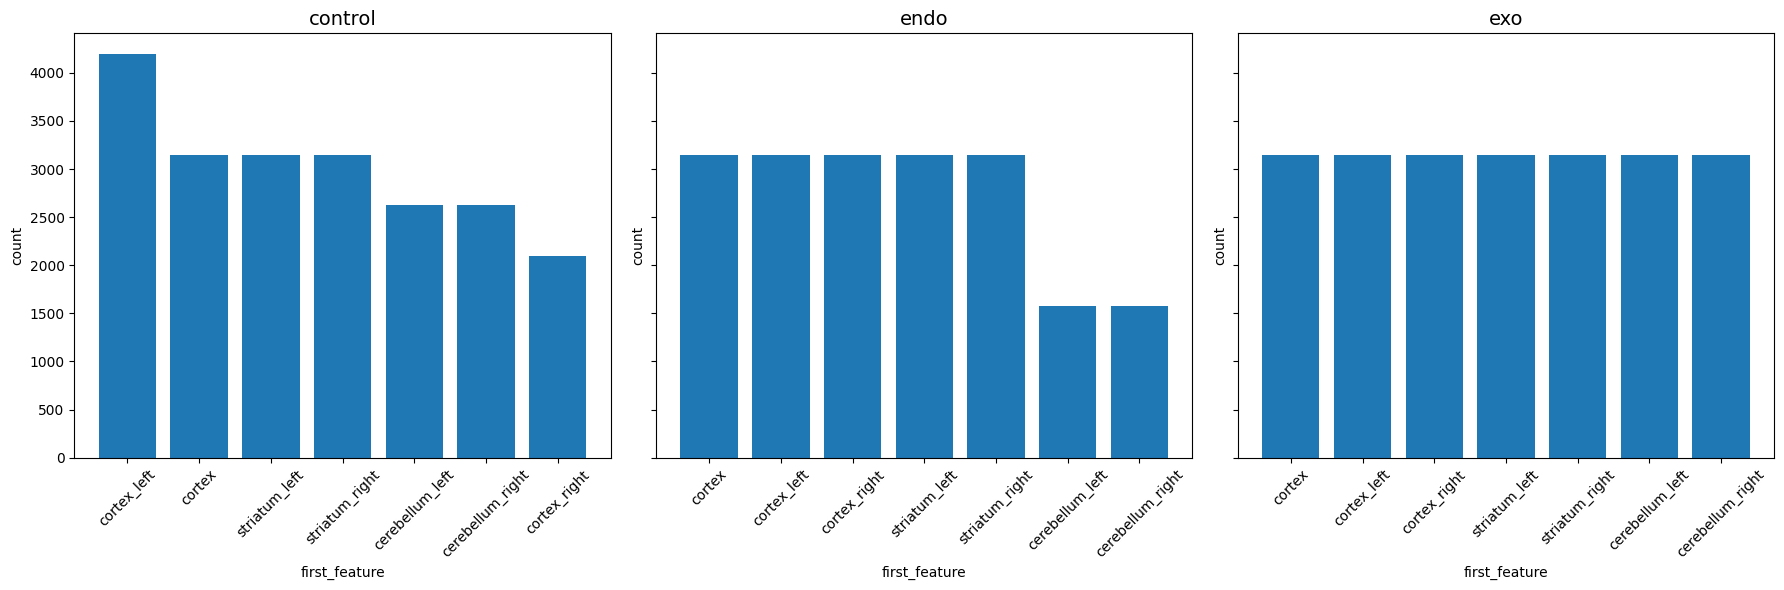

In [39]:
import matplotlib.pyplot as plt

labels = ["control", "endo", "exo"]

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

for i, label in enumerate(labels):

    subset = df[df["second_feature"] == label]
    
    counts = subset["first_feature"].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(label, fontsize=14)
    axes[i].set_xlabel("first_feature")
    axes[i].set_ylabel("count")

    # делаем подписи читаемыми
    axes[i].tick_params(axis='x', labelrotation=45, labelsize=10)

plt.tight_layout()
plt.show()

In [40]:
df["first_feature_clean"] = df["first_feature"].str.replace("_left", "", regex=False)\
                                              .str.replace("_right", "", regex=False)

C:\Users\pavel\AppData\Local\Temp\ipykernel_10716\3644029046.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["first_feature_clean"] = df["first_feature"].str.replace("_left", "", regex=False)\


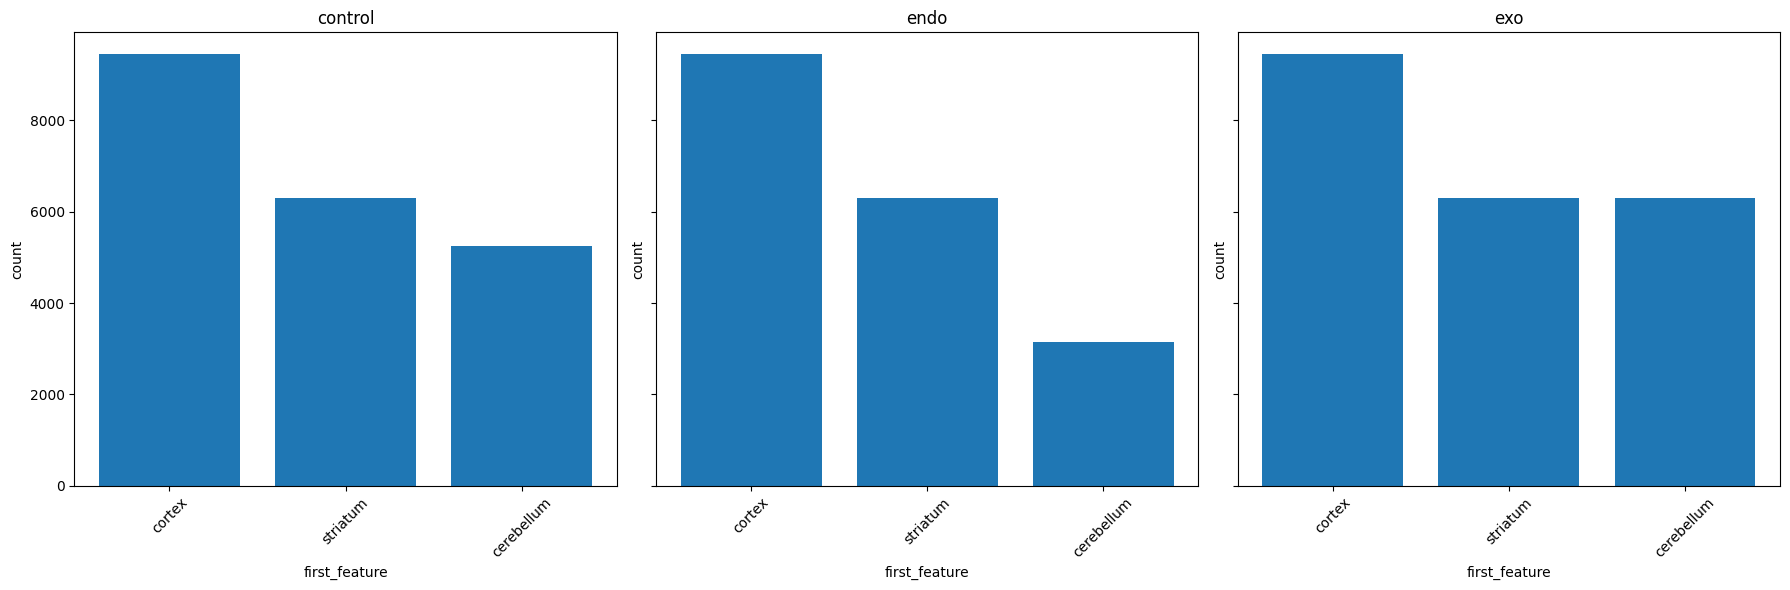

In [41]:
import matplotlib.pyplot as plt

labels = ["control", "endo", "exo"]

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

for i, label in enumerate(labels):

    subset = df[df["second_feature"] == label]

    counts = subset["first_feature_clean"].value_counts()

    axes[i].bar(counts.index, counts.values)

    axes[i].set_title(label)
    axes[i].set_xlabel("first_feature")
    axes[i].set_ylabel("count")

    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

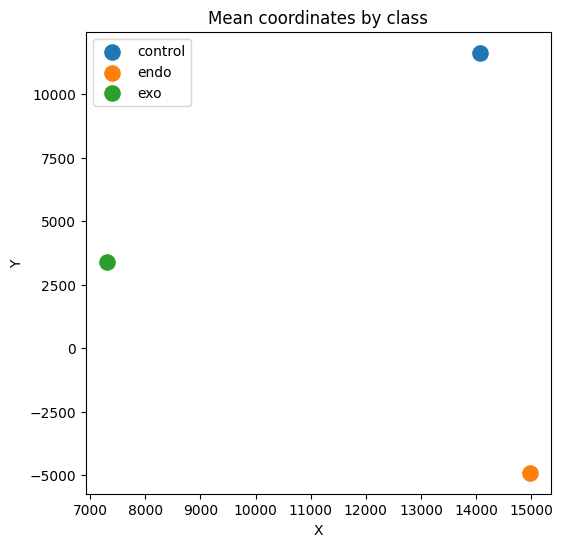

In [34]:
import matplotlib.pyplot as plt

# средние координаты по классам
mean_xy = df.groupby("second_feature")[["X", "Y"]].mean()

plt.figure(figsize=(6,6))

for label, row in mean_xy.iterrows():
    plt.scatter(row["X"], row["Y"], label=label, s=120)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mean coordinates by class")
plt.legend()

plt.show()

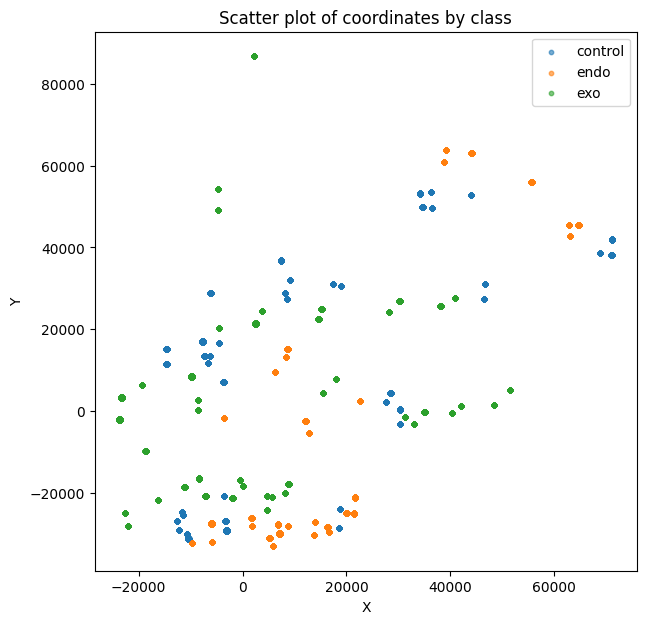

In [37]:
import matplotlib.pyplot as plt

colors = {
    "control": "tab:blue",
    "endo": "tab:orange",
    "exo": "tab:green"
}

plt.figure(figsize=(7,7))

for label, color in colors.items():

    subset = df[df["second_feature"] == label]

    plt.scatter(
        subset["X"],
        subset["Y"],
        color=color,
        label=label,
        alpha=0.6,
        s=10
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter plot of coordinates by class")
plt.legend()

plt.show()

In [10]:
cols_to_drop = ["X", "Y"] + ["first_feature"] + [f"param_{i}" for i in range(1, 12)]

X = df.drop(columns=cols_to_drop)

In [11]:
X

,second_feature,Wave_926.755,Wave_927.928,Wave_929.101,Wave_930.273,Wave_931.446,Wave_932.618,Wave_933.790,Wave_934.962,Wave_936.134,...,Wave_1993.771,Wave_1994.733,Wave_1995.694,Wave_1996.655,Wave_1997.616,Wave_1998.577,Wave_1999.538,Wave_2000.498,Wave_2001.458,Wave_2002.418
0,control,11524.832031,11415.909180,11486.722656,11452.671875,11461.430664,11498.032227,11583.915039,11543.429688,11650.786133,...,12658.952148,12875.486328,13037.258789,12694.952148,12942.969727,13076.103516,12984.517578,12979.162109,13013.024414,12803.853516
1,control,8786.427734,8709.043945,8620.927734,8721.156250,8772.179688,8733.279297,8638.670898,9028.212891,8595.052734,...,10330.268555,10418.412109,10545.763672,10594.799805,10573.313477,10632.827148,10415.318359,10281.377930,10419.309570,10437.611328
2,control,8493.333008,8475.804688,8430.445313,8646.232422,8465.999023,8521.264648,8499.440430,8460.468750,8515.766602,...,9753.319336,9773.462891,10046.941406,9724.959961,9988.084961,10023.967773,9903.046875,10035.650391,10021.884766,9919.914063
3,control,7338.068359,7292.486816,7379.583008,7143.470703,7230.571777,7339.124023,7216.384766,7322.836426,7418.617188,...,9165.926758,9102.402344,9370.529297,9348.813477,9175.556641,9305.356445,9176.457031,9251.411133,9098.919922,9245.338867
4,control,6362.511719,6271.795410,6326.579590,6494.842773,6329.158691,6452.518555,6503.100098,6397.305176,6469.325684,...,8899.642578,8846.510742,8950.057617,8938.708984,8885.554688,9030.978516,8860.208008,8825.307617,8918.510742,8936.812500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61945,exo,8580.944336,8783.832031,8781.341797,8629.003906,8744.241211,8690.343750,8490.771484,8535.351563,8616.378906,...,9781.923828,9794.239258,9848.344727,9878.962891,9776.349609,9958.525391,9866.342773,9821.178711,9932.874023,9972.092773
61946,exo,7393.603516,7348.034180,7360.232422,7481.609375,7412.478516,7422.555664,7372.662598,7434.153809,7334.957520,...,8588.878906,8621.854492,8699.241211,8609.481445,8679.057617,8772.177734,8763.403320,8610.849609,8771.990234,8798.135742
61947,exo,7479.177734,7465.722656,7409.457520,7428.092773,7500.263184,7398.999023,7436.921387,7408.445313,7409.957031,...,8505.339844,8347.689453,8229.152344,8484.101563,8321.130859,8343.628906,8483.748047,8514.127930,8377.185547,8497.457031
61948,exo,8756.371094,8691.821289,8704.293945,8783.130859,8842.731445,8596.116211,8565.740234,8696.032227,8689.235352,...,9471.261719,9460.018555,9600.243164,9513.268555,9632.656250,9488.166992,9489.984375,9491.801758,9514.537109,9702.788086


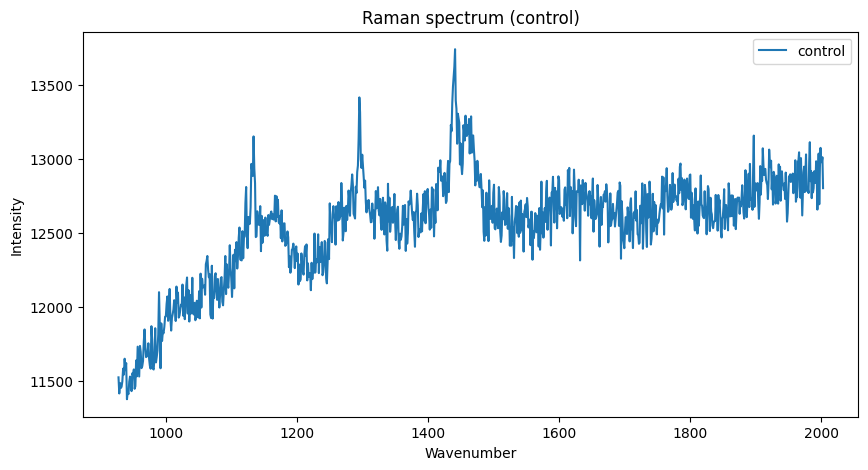

In [14]:
import matplotlib.pyplot as plt

row_index = 0   # номер строки

row = df.iloc[row_index]

# все спектральные колонки
wave_cols = [c for c in df.columns if c.startswith("Wave_")]

# x = волновые числа
x = [float(c.split("_")[1]) for c in wave_cols]

# y = интенсивности
y = row[wave_cols].values

label = row["second_feature"]

plt.figure(figsize=(10,5))
plt.plot(x, y, label=label)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity")
plt.title(f"Raman spectrum ({label})")
plt.legend()

plt.show()

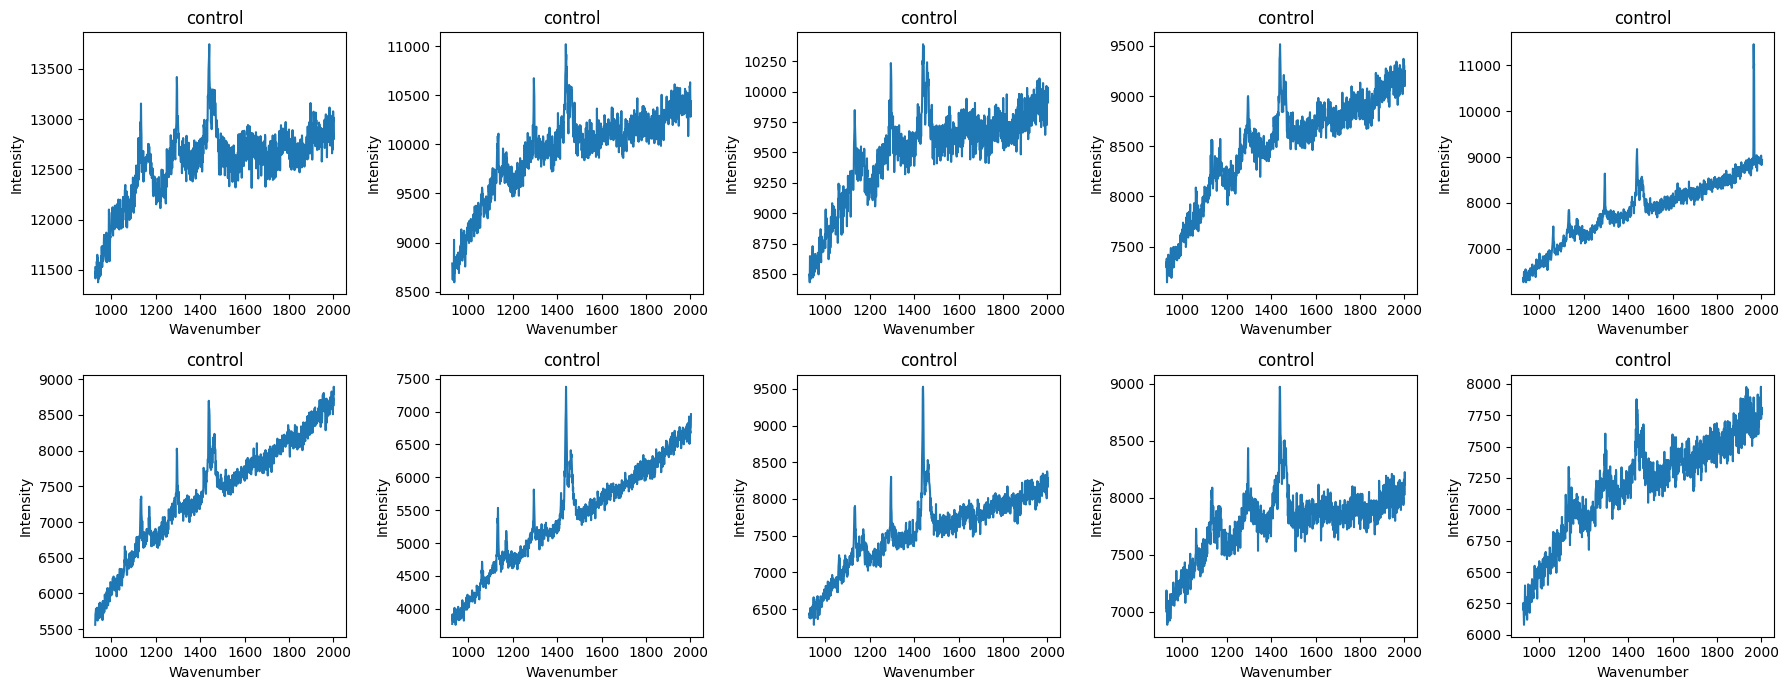

In [20]:
import matplotlib.pyplot as plt

# спектральные колонки
wave_cols = [c for c in df.columns if c.startswith("Wave_")]

# ось X
x = [float(c.split("_")[1]) for c in wave_cols]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

axes = axes.flatten()

for i in range(10):

    row = df.iloc[i]
    y = row[wave_cols].values
    label = row["second_feature"]

    axes[i].plot(x, y)
    axes[i].set_title(label)
    axes[i].set_xlabel("Wavenumber")
    axes[i].set_ylabel("Intensity")

plt.tight_layout()
plt.show()

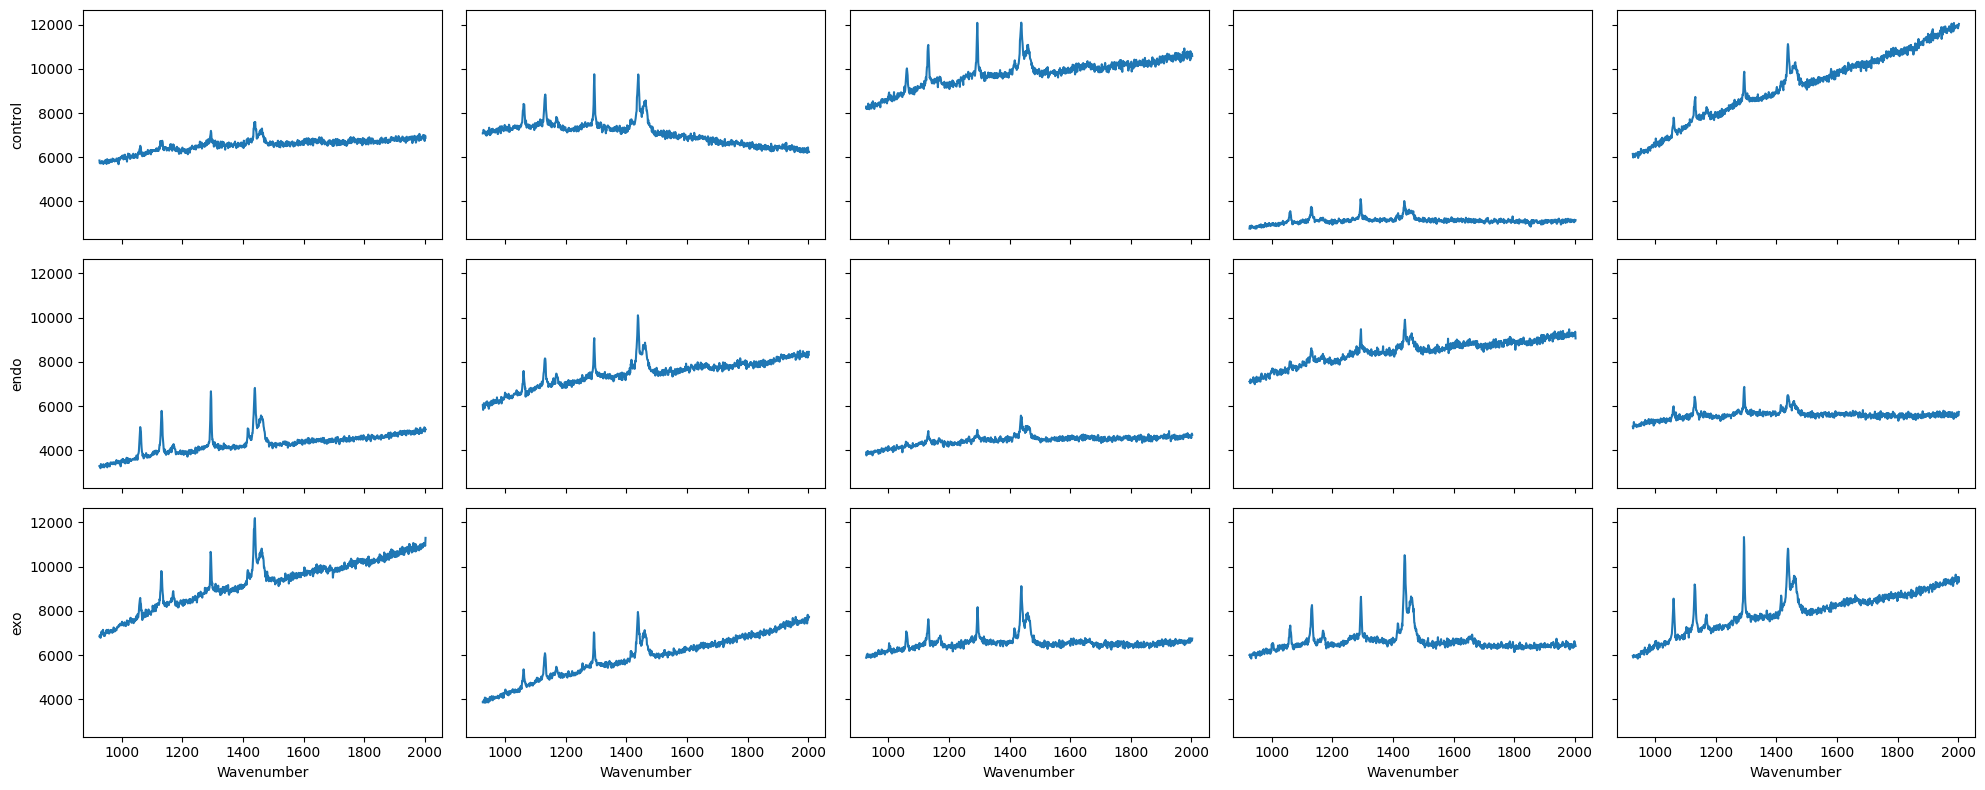

In [22]:
import matplotlib.pyplot as plt

# спектральные колонки
wave_cols = sorted(
    [c for c in df.columns if c.startswith("Wave_")],
    key=lambda c: float(c.split("_")[1])
)

# ось X
x = [float(c.split("_")[1]) for c in wave_cols]

labels = ["control", "endo", "exo"]

fig, axes = plt.subplots(3, 5, figsize=(20, 8), sharex=True, sharey=True)

for row_i, label in enumerate(labels):

    subset = df[df["second_feature"] == label].sample(5, random_state=42)

    for col_i in range(5):

        row = subset.iloc[col_i]
        y = row[wave_cols].values

        ax = axes[row_i, col_i]
        ax.plot(x, y)

        if col_i == 0:
            ax.set_ylabel(label)

        if row_i == 2:
            ax.set_xlabel("Wavenumber")

plt.tight_layout()
plt.show()

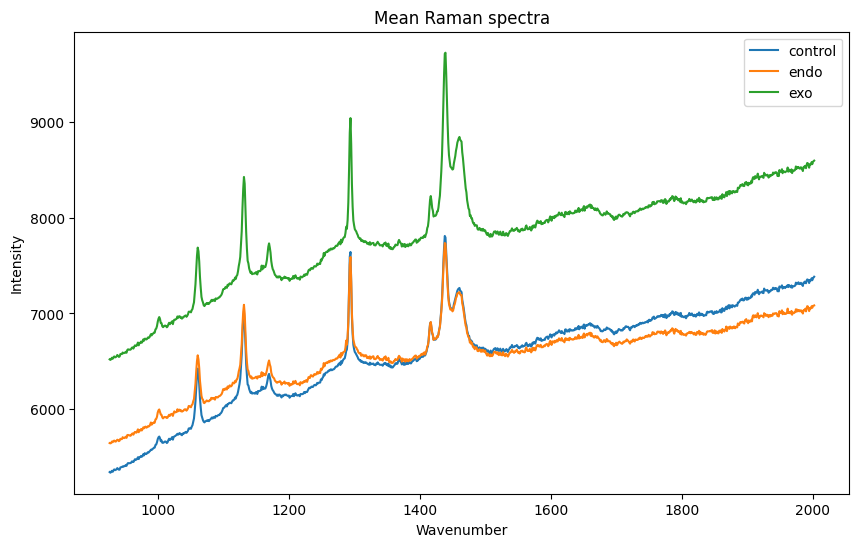

In [25]:
import matplotlib.pyplot as plt

# спектральные колонки
wave_cols = [c for c in df.columns if c.startswith("Wave_")]

# извлекаем волновые числа для оси X
x = [float(c.split("_")[1]) for c in wave_cols]

# средние спектры по классам
mean_spectra = df.groupby("second_feature")[wave_cols].mean()

plt.figure(figsize=(10,6))

for label in ["control", "endo", "exo"]:
    y = mean_spectra.loc[label].values
    plt.plot(x, y, label=label)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity")
plt.title("Mean Raman spectra")
plt.legend()

plt.show()

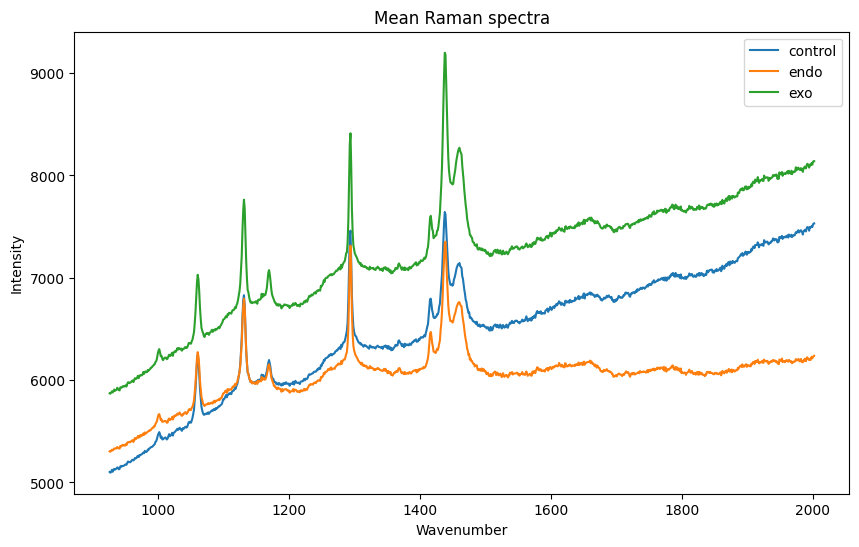

In [45]:
import matplotlib.pyplot as plt

# спектральные колонки
wave_cols = [c for c in df.columns if c.startswith("Wave_")]

# извлекаем волновые числа для оси X
x = [float(c.split("_")[1]) for c in wave_cols]

# средние спектры по классам
mean_spectra = df.groupby("second_feature")[wave_cols].median()

plt.figure(figsize=(10,6))

for label in ["control", "endo", "exo"]:
    y = mean_spectra.loc[label].values
    plt.plot(x, y, label=label)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity")
plt.title("Mean Raman spectra")
plt.legend()

plt.show()

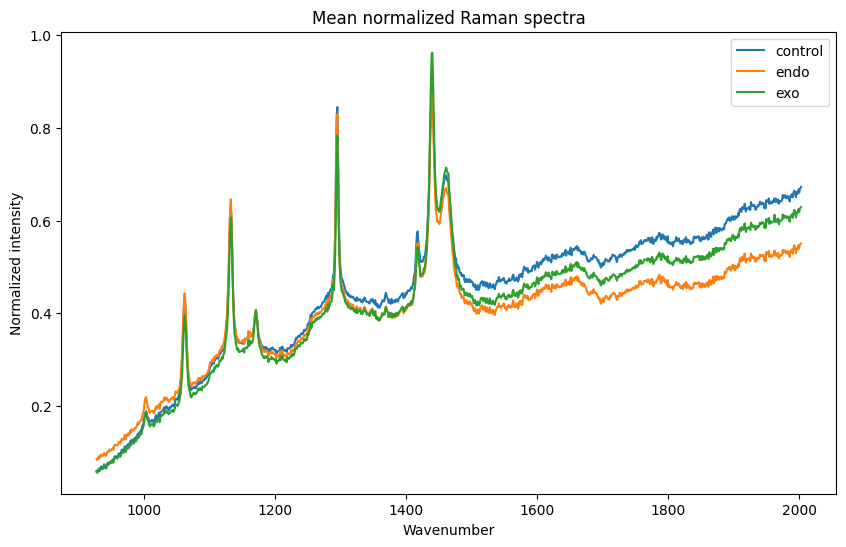

In [44]:
import matplotlib.pyplot as plt

wave_cols = [c for c in df.columns if c.startswith("Wave_")]

# нормализация каждой строки
spectra = df[wave_cols]
spectra_norm = (spectra - spectra.min(axis=1).values[:, None]) / \
               (spectra.max(axis=1) - spectra.min(axis=1)).values[:, None]

# считаем средние спектры
mean_spectra = spectra_norm.groupby(df["second_feature"]).mean()

# ось X
x = [float(c.split("_")[1]) for c in wave_cols]

plt.figure(figsize=(10,6))

for label in ["control", "endo", "exo"]:
    y = mean_spectra.loc[label].values
    plt.plot(x, y, label=label)

plt.xlabel("Wavenumber")
plt.ylabel("Normalized intensity")
plt.title("Mean normalized Raman spectra")
plt.legend()

plt.show()

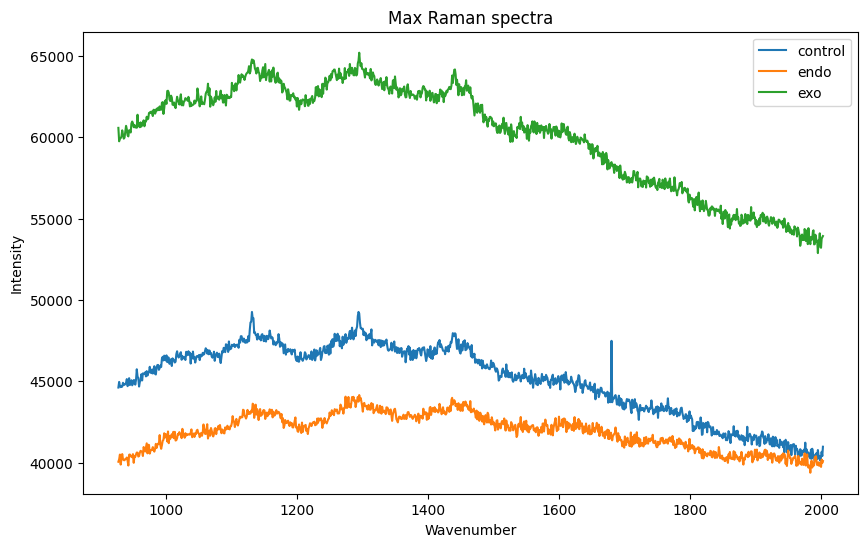

In [43]:
import matplotlib.pyplot as plt

# спектральные колонки
wave_cols = [c for c in df.columns if c.startswith("Wave_")]

# извлекаем волновые числа для оси X
x = [float(c.split("_")[1]) for c in wave_cols]

# средние спектры по классам
max_spectra = df.groupby("second_feature")[wave_cols].max()

plt.figure(figsize=(10,6))

for label in ["control", "endo", "exo"]:
    y = max_spectra.loc[label].values
    plt.plot(x, y, label=label)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity")
plt.title("Max Raman spectra")
plt.legend()

plt.show()

In [28]:
max_spectra

,Wave_926.755,Wave_927.928,Wave_929.101,Wave_930.273,Wave_931.446,Wave_932.618,Wave_933.790,Wave_934.962,Wave_936.134,Wave_937.306,...,Wave_1993.771,Wave_1994.733,Wave_1995.694,Wave_1996.655,Wave_1997.616,Wave_1998.577,Wave_1999.538,Wave_2000.498,Wave_2001.458,Wave_2002.418
second_feature,,,,,,,,,,,,,,,,,,,,,
control,44619.199219,44964.242188,44705.871094,44642.195313,44694.121094,44671.109375,44911.558594,44770.750000,44794.882813,44827.605469,...,40217.054688,40778.308594,40436.152344,40250.589844,40409.828125,40119.664063,40399.167969,40670.933594,40406.804688,40982.027344
endo,40060.179688,40209.570313,40500.277344,39885.585938,40234.156250,40529.332031,40212.011719,40158.085938,40151.281250,40228.062500,...,39851.593750,39992.382813,40023.539063,39809.164063,39884.714844,40002.101563,39743.167969,40189.960938,39985.875000,40106.148438
exo,60574.843750,59750.507813,59953.167969,59941.835938,60046.125000,60422.437500,60182.003906,59913.617188,59975.132813,60332.449219,...,53601.890625,52881.023438,53672.023438,53627.437500,54094.917969,53240.320313,53208.695313,53770.476563,53851.371094,53927.199219


In [30]:
max_spectra.max(axis=1)

second_feature
control    49264.691406
endo       44154.968750
exo        65192.691406
dtype: float64

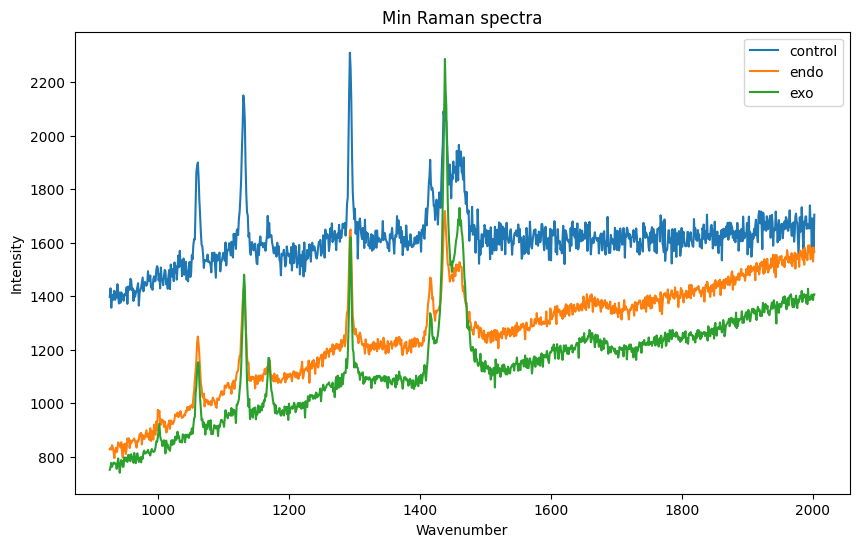

In [42]:
import matplotlib.pyplot as plt

# спектральные колонки
wave_cols = [c for c in df.columns if c.startswith("Wave_")]

# извлекаем волновые числа для оси X
x = [float(c.split("_")[1]) for c in wave_cols]

# средние спектры по классам
min_spectra = df.groupby("second_feature")[wave_cols].min()

plt.figure(figsize=(10,6))

for label in ["control", "endo", "exo"]:
    y = min_spectra.loc[label].values
    plt.plot(x, y, label=label)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity")
plt.title("Min Raman spectra")
plt.legend()

plt.show()

In [33]:
min_spectra.min(axis=1)

second_feature
control    1356.930542
endo        794.686890
exo         740.037170
dtype: float64